In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression,LassoCV,RidgeCV
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder,PowerTransformer,label_binarize,RobustScaler
from sklearn.model_selection import train_test_split,learning_curve,GridSearchCV,cross_val_score, StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,confusion_matrix,classification_report,silhouette_score,roc_curve,auc, RocCurveDisplay,recall_score,roc_auc_score,davies_bouldin_score,f1_score,precision_recall_curve,ConfusionMatrixDisplay,average_precision_score
from sklearn.datasets import make_classification,make_blobs
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,BaggingClassifier,AdaBoostClassifier,IsolationForest,RandomForestRegressor,VotingClassifier
from sklearn.cluster import KMeans,DBSCAN
from scipy.cluster.hierarchy import dendrogram,linkage
from scipy.spatial.distance import euclidean,cityblock,cosine
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris,load_digits
from mlxtend.frequent_patterns import apriori,association_rules
from scipy.stats import mode
from sklearn.neighbors import NearestNeighbors
import joblib
import warnings
from mpl_toolkits.mplot3d import Axes3D
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
import plotly.express as px
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
import os
from xgboost import XGBClassifier
import time
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('breast-cancer.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.describe(include='object')

,diagnosis
count,569
unique,2
top,B
freq,357


In [ ]:
df.nunique()

,0
id,569
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave points_mean,542


In [ ]:
df.shape

(569, 32)

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 's

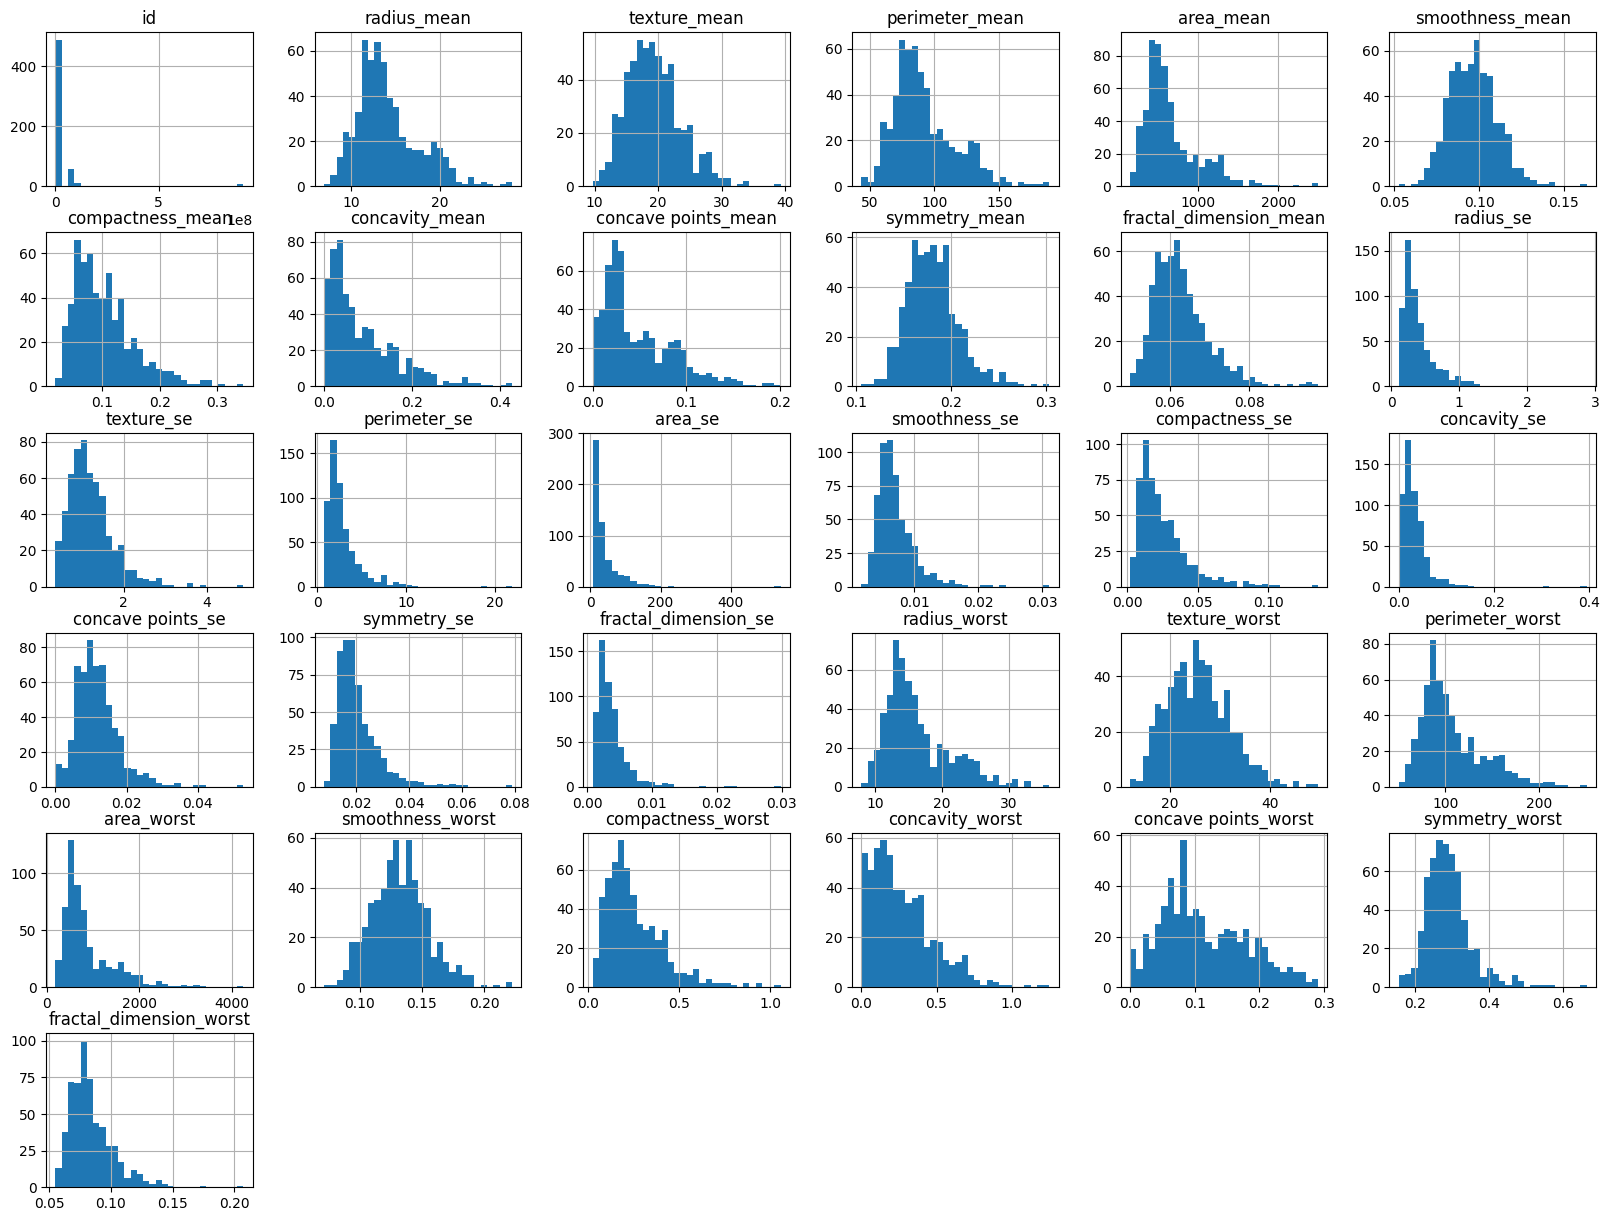

In [ ]:
df.hist(bins=30,figsize=(20,15))

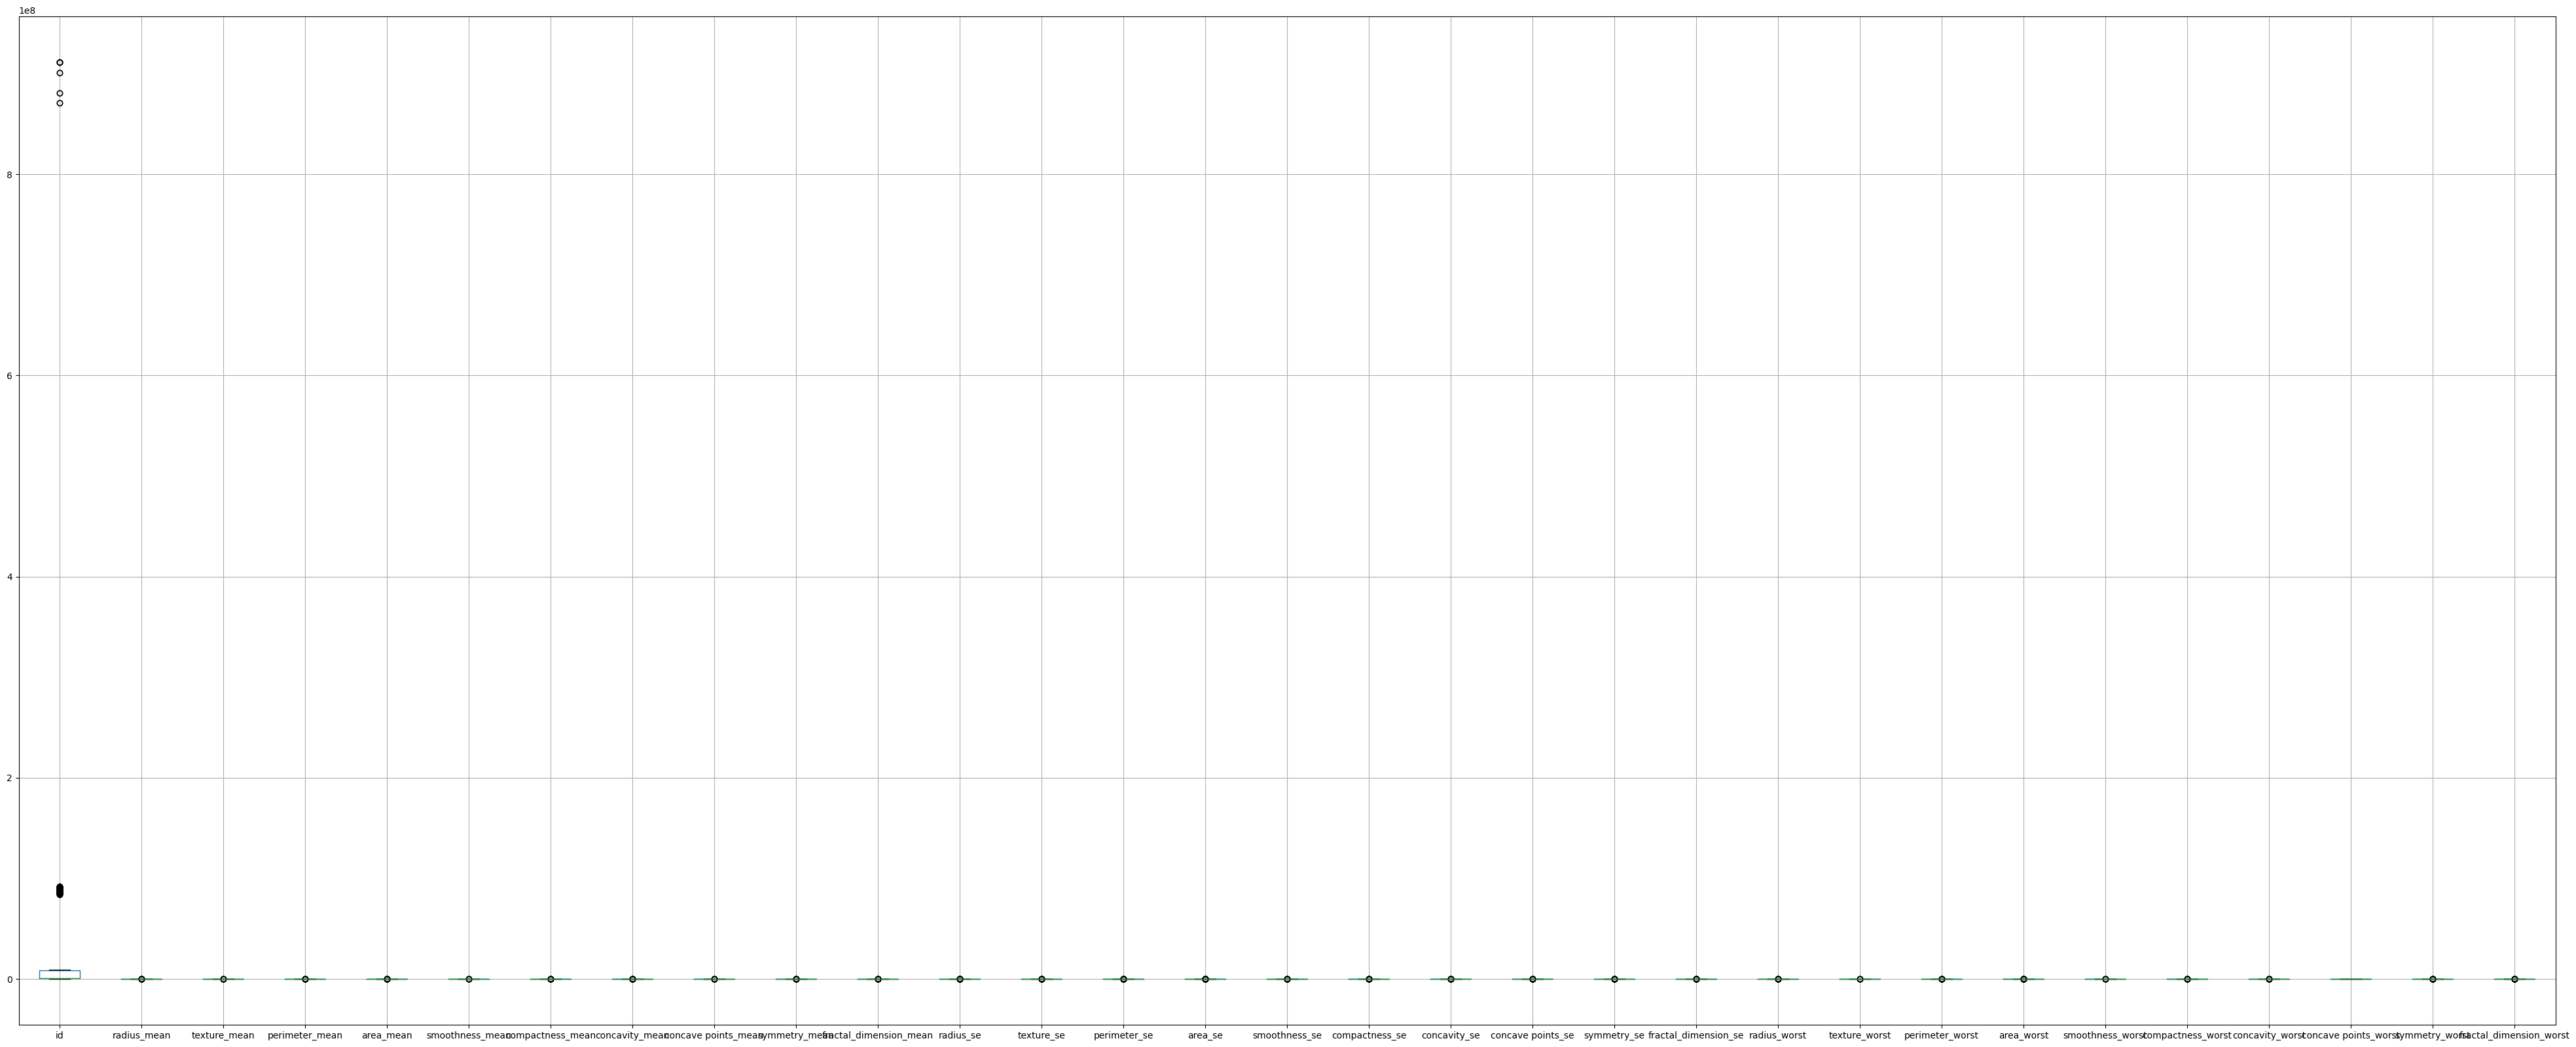

In [ ]:
df.boxplot(figsize=(50,20))
plt.show()

In [ ]:
df.drop(columns='id',inplace=True)

In [ ]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

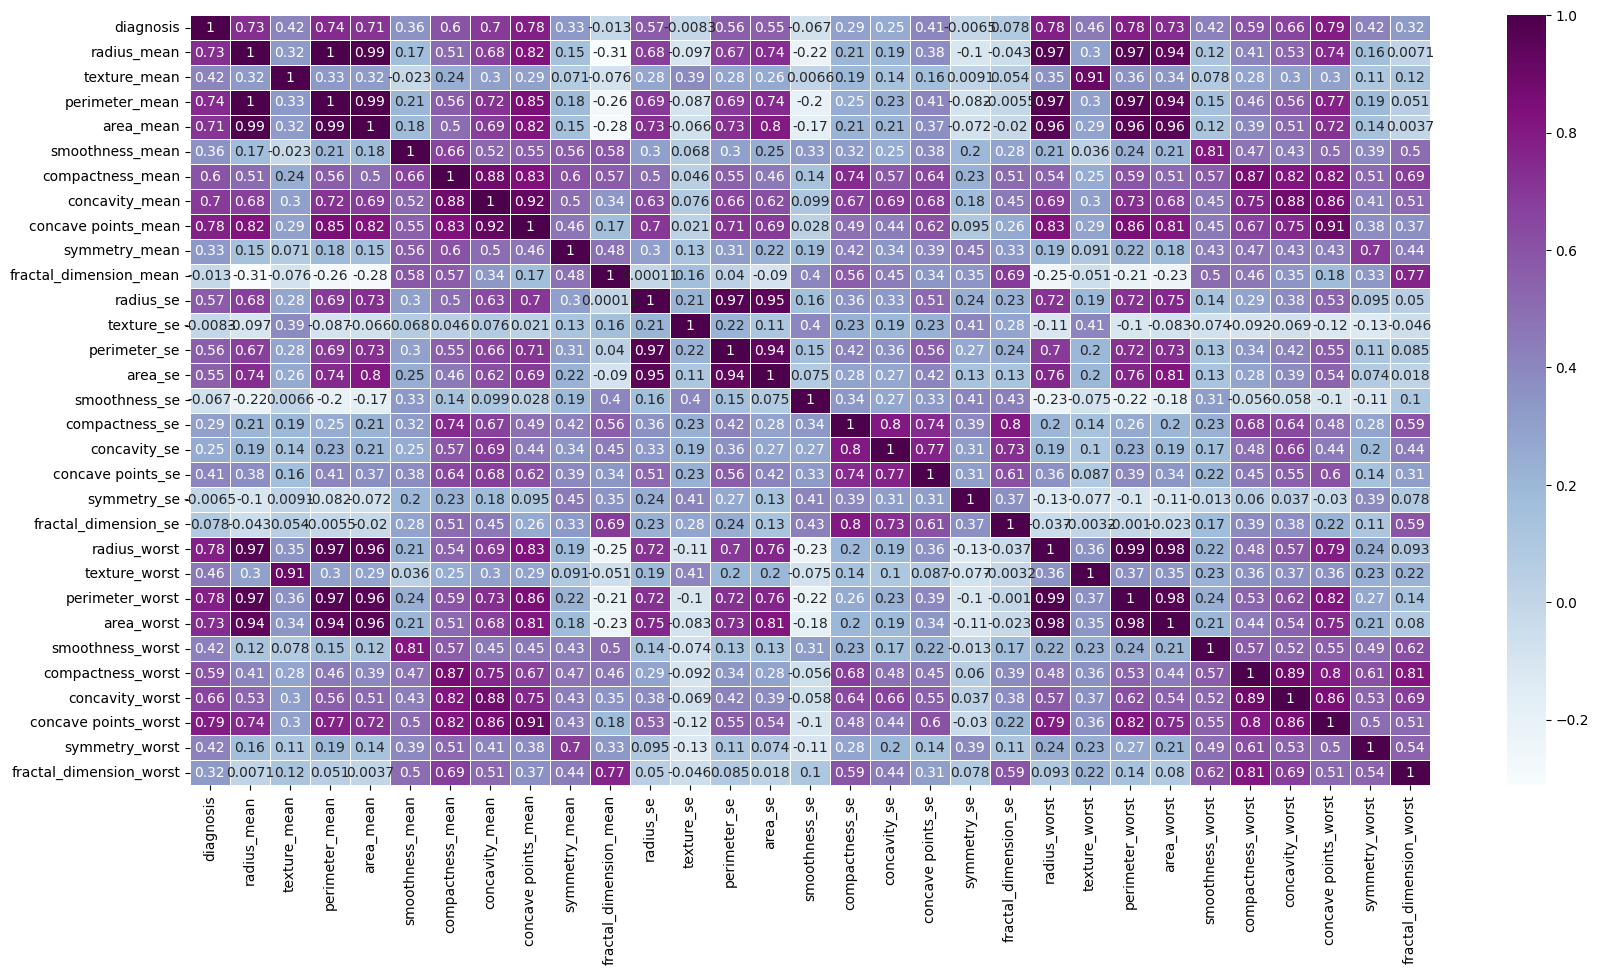

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True,cmap='BuPu',linewidths=0.5)
plt.show()

In [ ]:
df.drop(columns=['concave points_mean','concavity_mean','radius_mean','perimeter_mean','area_mean','perimeter_worst','area_worst'
,'concavity_worst','compactness_worst','smoothness_mean','texture_mean','fractal_dimension_se',
                 'symmetry_se','smoothness_se','texture_se','perimeter_se','area_se','fractal_dimension_mean'],inplace=True)
df

,diagnosis,compactness_mean,symmetry_mean,radius_se,compactness_se,concavity_se,concave points_se,radius_worst,texture_worst,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,0.27760,0.2419,1.0950,0.04904,0.05373,0.01587,25.380,17.33,0.16220,0.2654,0.4601,0.11890
1,1,0.07864,0.1812,0.5435,0.01308,0.01860,0.01340,24.990,23.41,0.12380,0.1860,0.2750,0.08902
2,1,0.15990,0.2069,0.7456,0.04006,0.03832,0.02058,23.570,25.53,0.14440,0.2430,0.3613,0.08758
3,1,0.28390,0.2597,0.4956,0.07458,0.05661,0.01867,14.910,26.50,0.20980,0.2575,0.6638,0.17300
4,1,0.13280,0.1809,0.7572,0.02461,0.05688,0.01885,22.540,16.67,0.13740,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,0.11590,0.1726,1.1760,0.02891,0.05198,0.02454,25.450,26.40,0.14100,0.2216,0.2060,0.07115
565,1,0.10340,0.1752,0.7655,0.02423,0.03950,0.01678,23.690,38.25,0.11660,0.1628,0.2572,0.06637
566,1,0.10230,0.1590,0.4564,0.03731,0.04730,0.01557,18.980,34.12,0.11390,0.1418,0.2218,0.07820
567,1,0.27700,0.2397,0.7260,0.06158,0.07117,0.01664,25.740,39.42,0.16500,0.2650,0.4087,0.12400


<Axes: >

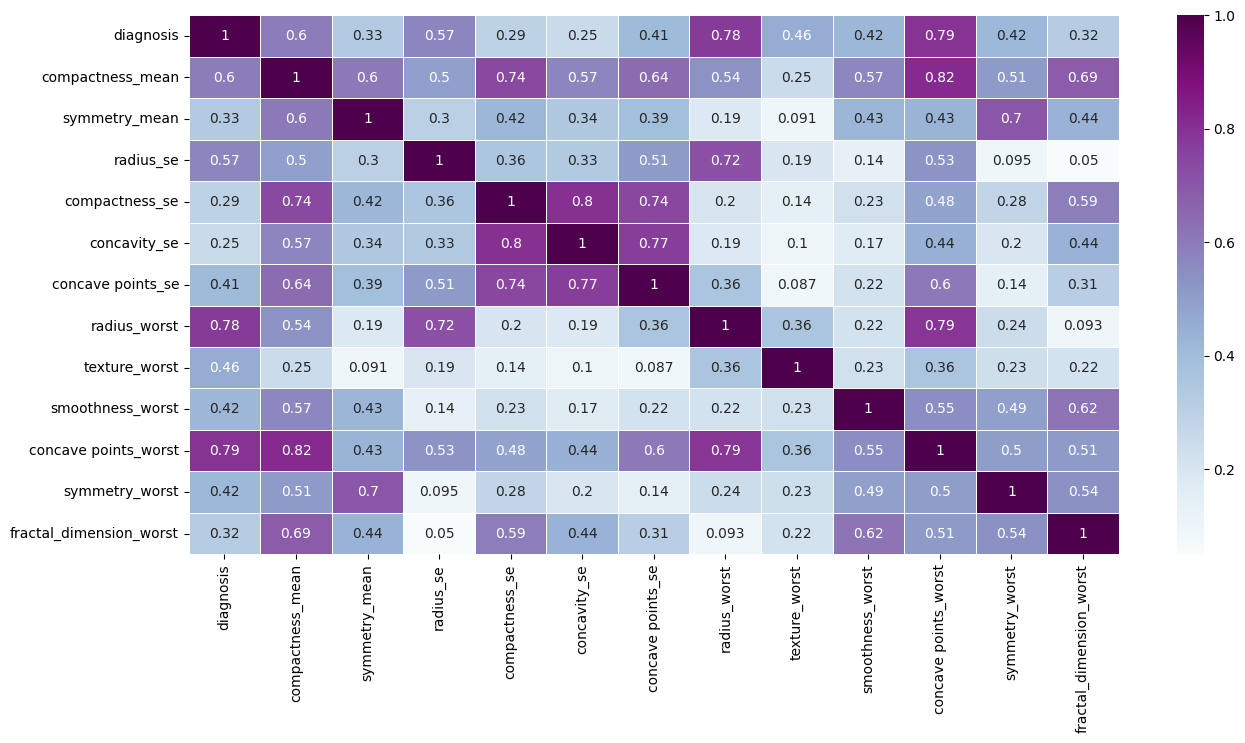

In [ ]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(),annot=True,cmap='BuPu',linewidths=0.5)

In [ ]:
df['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
0,0.627417
1,0.372583


array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'radius_worst'}>],
       [<Axes: title={'center': 'texture_worst'}>,
        <Axes: title={'center': 'smoothness_worst'}>,
        <Axes: title={'center': 'concave points_worst'}>,
        <Axes: title={'center': 'symmetry_worst'}>],
       [<Axes: title={'center': 'fractal_dimension_worst'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

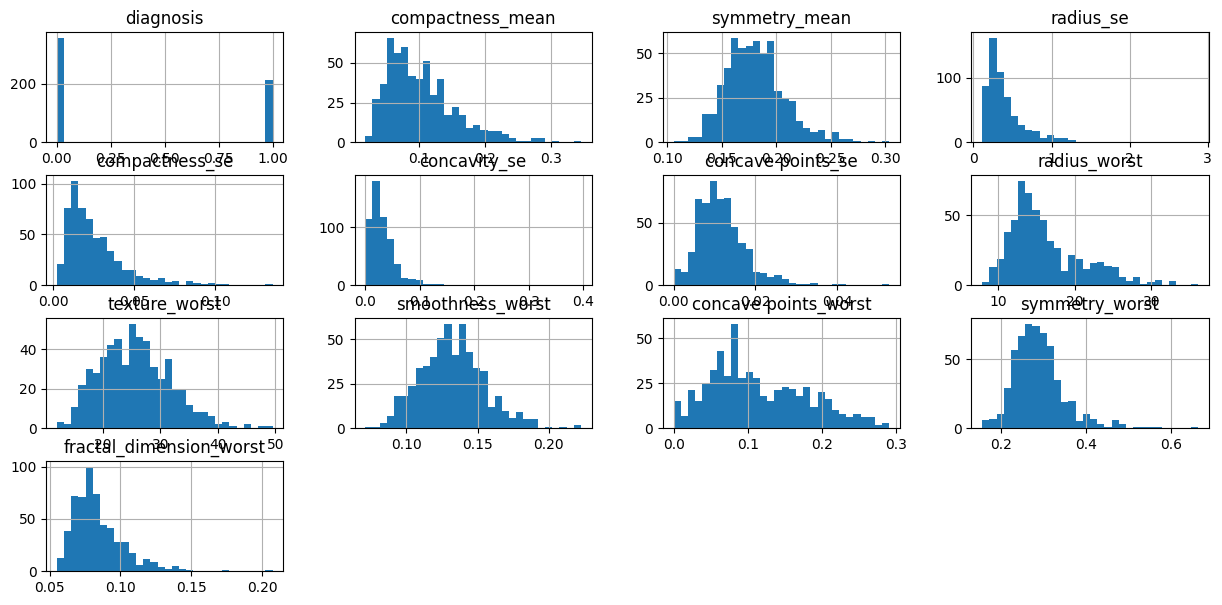

In [ ]:
df.hist(bins=30,figsize=(15,7))

In [ ]:
cols=['compactness_mean','symmetry_mean','radius_se','compactness_se','concavity_se','concave points_se','radius_worst','texture_worst','smoothness_worst','concave points_worst','symmetry_worst','fractal_dimension_worst']

In [ ]:
for col in cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df[col]=np.clip(df[col],lower,upper)

array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'radius_worst'}>],
       [<Axes: title={'center': 'texture_worst'}>,
        <Axes: title={'center': 'smoothness_worst'}>,
        <Axes: title={'center': 'concave points_worst'}>,
        <Axes: title={'center': 'symmetry_worst'}>],
       [<Axes: title={'center': 'fractal_dimension_worst'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

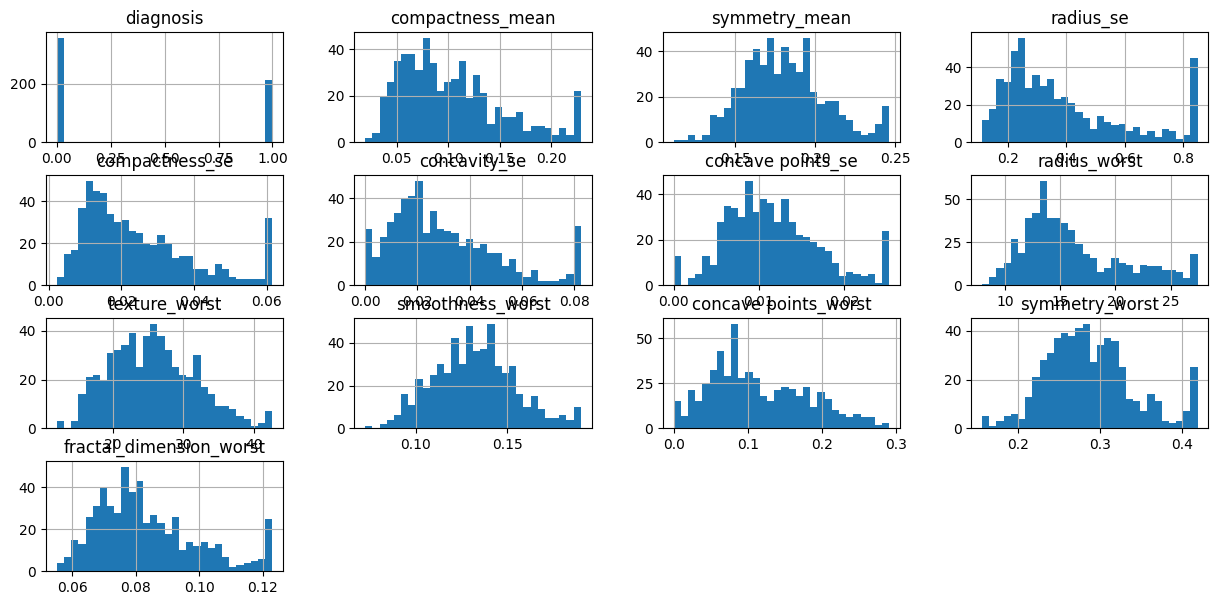

In [ ]:
df.hist(bins=30,figsize=(15,7))

In [ ]:
print("Before Yeo-Johnson")
print(df[cols].skew())

pt=PowerTransformer(method='yeo-johnson')
df[cols]=pt.fit_transform(df[cols])

print("After Yeo-Johnson")
print(df[cols].skew())

Before Yeo-Johnson
compactness_mean           0.826755
symmetry_mean              0.403621
radius_se                  1.025031
compactness_se             0.990285
concavity_se               0.916740
concave points_se          0.539571
radius_worst               0.849779
texture_worst              0.386858
smoothness_worst           0.247199
concave points_worst       0.492616
symmetry_worst             0.521772
fractal_dimension_worst    0.831581
dtype: float64
After Yeo-Johnson
compactness_mean           0.102176
symmetry_mean              0.005121
radius_se                  0.157291
compactness_se             0.170630
concavity_se               0.102595
concave points_se          0.006558
radius_worst               0.034750
texture_worst             -0.008927
smoothness_worst           0.005460
concave points_worst       0.050211
symmetry_worst            -0.001090
fractal_dimension_worst    0.080429
dtype: float64


array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'radius_worst'}>],
       [<Axes: title={'center': 'texture_worst'}>,
        <Axes: title={'center': 'smoothness_worst'}>,
        <Axes: title={'center': 'concave points_worst'}>,
        <Axes: title={'center': 'symmetry_worst'}>],
       [<Axes: title={'center': 'fractal_dimension_worst'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

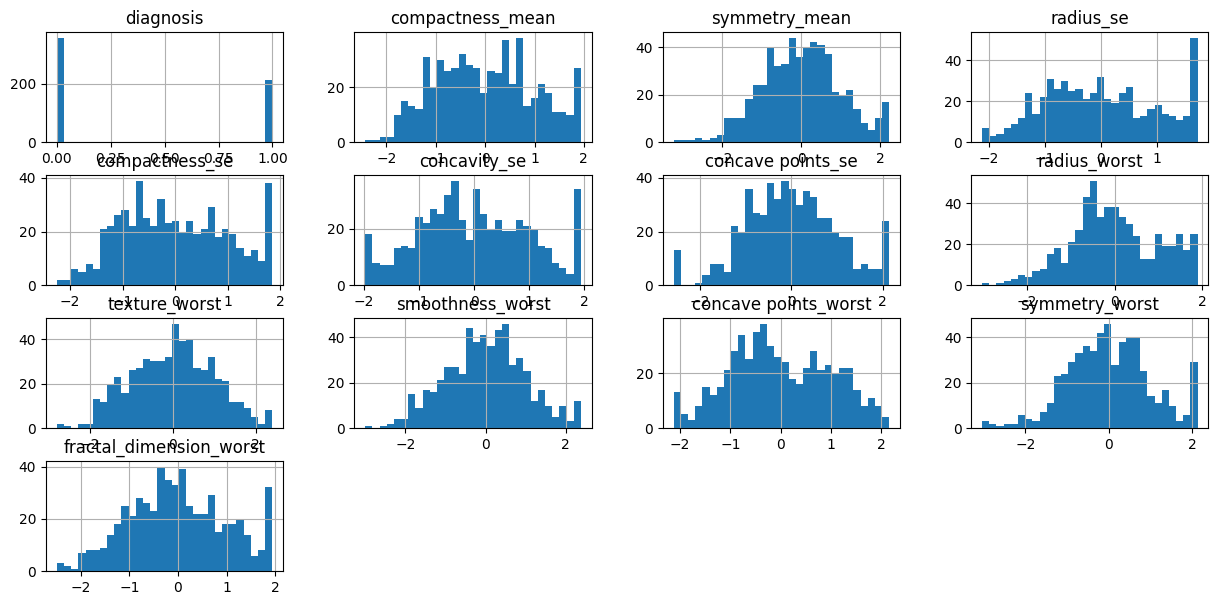

In [ ]:
df.hist(bins=30,figsize=(15,7))

In [ ]:
scaler=StandardScaler()
df[cols]=scaler.fit_transform(df[cols])
df

,diagnosis,compactness_mean,symmetry_mean,radius_se,compactness_se,concavity_se,concave points_se,radius_worst,texture_worst,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,1.939324,2.098277,1.737569,1.506588,1.206499,0.836387,1.674752,-1.485029,1.318152,1.935654,2.124369,1.825134
1,1,-0.394789,0.089075,0.998793,-0.801955,-0.477410,0.419944,1.630964,-0.297203,-0.340392,1.101594,-0.156175,0.539083
2,1,1.190133,1.019624,1.546945,1.158281,0.608181,1.539598,1.461711,0.064832,0.580950,1.722744,1.330307,0.452639
3,1,1.939324,2.223162,0.820127,1.848106,1.299724,1.267938,-0.092184,0.223334,2.374851,1.862378,2.124369,1.944290
4,1,0.769721,0.077429,1.570782,0.253713,1.308200,1.294298,1.328266,-1.630888,0.276411,0.807077,-0.969692,-0.294213
...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,0.458816,-0.252485,1.737569,0.553808,1.147253,2.049748,1.682496,0.207188,0.434098,1.503734,-1.690114,-0.763032
565,1,0.200511,-0.147519,1.587436,0.225056,0.660653,0.981180,1.476646,1.875071,-0.680995,0.810995,-0.518237,-1.211576
566,1,0.176519,-0.826761,0.654998,1.029286,0.978535,0.787660,0.779632,1.342611,-0.811330,0.526136,-1.306247,-0.185210
567,1,1.939324,2.036152,1.505128,1.848106,1.699318,0.959195,1.714215,2.018297,1.429467,1.931990,1.991013,1.944290


array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'radius_worst'}>],
       [<Axes: title={'center': 'texture_worst'}>,
        <Axes: title={'center': 'smoothness_worst'}>,
        <Axes: title={'center': 'concave points_worst'}>,
        <Axes: title={'center': 'symmetry_worst'}>],
       [<Axes: title={'center': 'fractal_dimension_worst'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

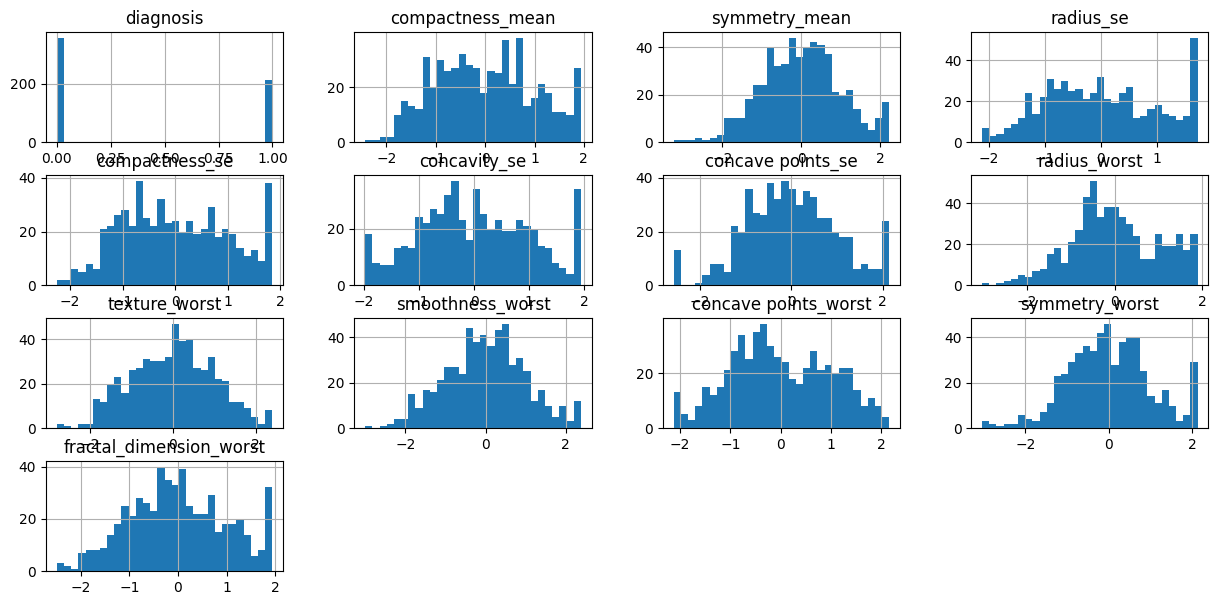

In [ ]:
df.hist(bins=30,figsize=(15,7))

In [ ]:
x=df.drop(columns='diagnosis')
y=df['diagnosis']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=df['diagnosis'])

In [ ]:
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)
y_pred_lr=lr_model.predict(x_test)

print(f"Baseline Linear Logistic Model Accuracy: {accuracy_score(y_test,y_pred_lr)}")

Baseline Linear Logistic Model Accuracy: 0.9824561403508771


In [ ]:
rf_model=RandomForestClassifier()
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)

print(f"Baseline Random Forest Model Accuracy: {accuracy_score(y_test,y_pred_rf)} ")

Baseline Random Forest Model Accuracy: 0.9649122807017544 


In [ ]:
gb_model=GradientBoostingClassifier()
gb_model.fit(x_train,y_train)
y_pred_gb=gb_model.predict(x_test)
print(f"Baseline Gradient Boosting Accuracy: {accuracy_score(y_test,y_pred_gb)}")

Baseline Gradient Boosting Accuracy: 0.956140350877193


In [ ]:
results={}
models = {
    "Logistic Regression": LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", n_estimators=300, random_state=42)
}

for name, model in models.items():
    start = time.time()
    model.fit(x_train, y_train)  # Use scaled data for LR, original is fine for trees
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    duration = time.time() - start
    report=classification_report(y_test,y_pred)

    results[name] = {
        "Accuracy": acc,
        "Time (s)": duration
    }

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Training + Prediction time: {duration:.2f} sec")
    print("Classification Report:")
    print(report)


Logistic Regression
Accuracy: 0.9737
Training + Prediction time: 0.02 sec
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Random Forest
Accuracy: 0.9737
Training + Prediction time: 0.57 sec
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


XGBoost
Accuracy: 0.9474
Training + Prediction time: 0.08 sec
Classification Report:
              precision    recall  f1-score   support

           0   

In [ ]:
models_and_grids = {
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200],
         'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5],
         'class_weight': [None, 'balanced']}
    ),

    "DecisionTree": (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5],
         'class_weight': [None, 'balanced']}
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200],
         'learning_rate': [0.05, 0.1, 0.2],
         'max_depth': [3, 5]}
    ),

    "SVM": (
        SVC(probability=True, random_state=42),
        {'C': [1, 10],
         'kernel': ['linear', 'rbf'],
         'class_weight': [None, 'balanced']}
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.1, 1, 10],
         'penalty': ['l2'],
         'class_weight': [None, 'balanced']}
    ),

    "KNN": (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7],
         'weights': ['uniform', 'distance']}
    )
}

# --------------------------
# 4. Train & evaluate
# --------------------------
results = {}
for name, (model, param_grid) in models_and_grids.items():
    print(f"\n🔍 Training {name}...")
    Xtr, Xte = x_train,x_test
    grid = GridSearchCV(model, param_grid, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(Xtr, y_train)
    y_pred = grid.best_estimator_.predict(Xte)

    print(f"✅ Best {name}: {grid.best_params_}")
    print(classification_report(y_test, y_pred, digits=3))
    results[name] = (grid.best_params_, classification_report(y_test, y_pred, digits=3, output_dict=True))


🔍 Training RandomForest...
✅ Best RandomForest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0      0.947     1.000     0.973        72
           1      1.000     0.905     0.950        42

    accuracy                          0.965       114
   macro avg      0.974     0.952     0.961       114
weighted avg      0.967     0.965     0.965       114


🔍 Training DecisionTree...
✅ Best DecisionTree: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0      0.932     0.958     0.945        72
           1      0.925     0.881     0.902        42

    accuracy                          0.930       114
   macro avg      0.929     0.920     0.924       114
weighted avg      0.930     0.930     0.929       114


🔍 Training GradientBoosting...
✅ Best GradientBoosting: {'learning_rate': 0.1, 'ma

Confusion Matrix:
[[72  0]
 [ 2 40]]
ROC-AUC: 0.996031746031746


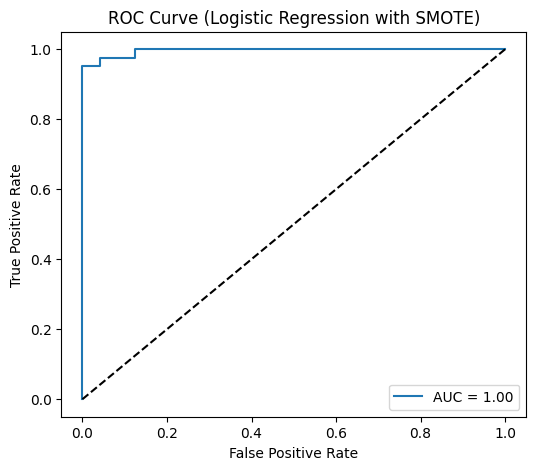

In [ ]:
y_proba_lr=lr_model.predict_proba(x_test)[:,1]
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm)

# ✅ ROC-AUC score
roc_auc = roc_auc_score(y_test,y_proba_lr)
print("ROC-AUC:", roc_auc)

# ✅ Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression with SMOTE)")
plt.legend()
plt.show()

                    Feature  Importance
6              radius_worst    2.807087
9      concave points_worst    1.648846
7             texture_worst    1.630255
2                 radius_se    1.407979
3            compactness_se    1.338009
4              concavity_se    0.909537
10           symmetry_worst    0.593567
8          smoothness_worst    0.533005
5         concave points_se    0.388843
11  fractal_dimension_worst    0.123750
0          compactness_mean    0.120877
1             symmetry_mean    0.098275


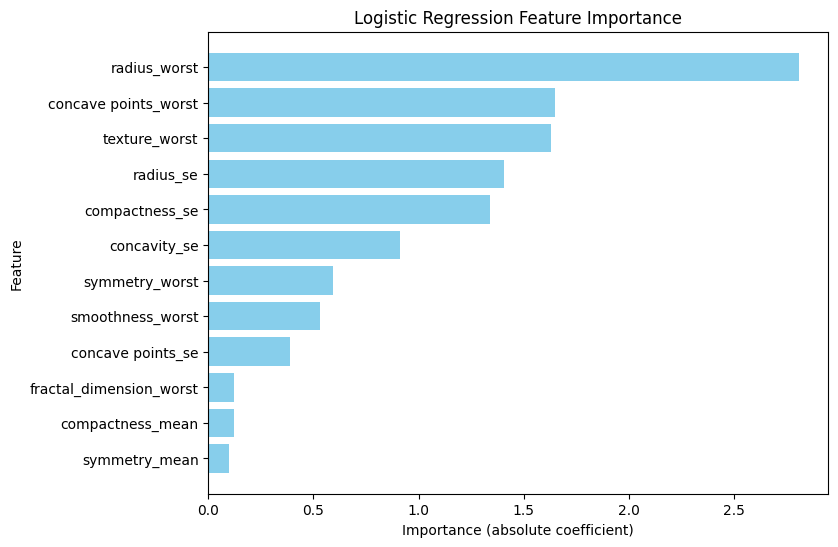

In [ ]:
feature_names = x_train.columns  # or use X.columns if you have the DataFrame
coefficients = lr_model.coef_[0]  # logistic regression coefficients

# ✅ Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)  # take absolute value
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# ✅ Plot feature importance
plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel("Importance (absolute coefficient)")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")
plt.gca().invert_yaxis()  # highest at top
plt.show()

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(lr_model,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.95614035 0.95614035 0.95614035 1.         0.98230088]
Mean CV accuracy: 0.9701443875174661
Std deviation: 0.018041491919132565


Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[72  0]
 [ 2 40]]
ROC-AUC: 0.9947089947089948


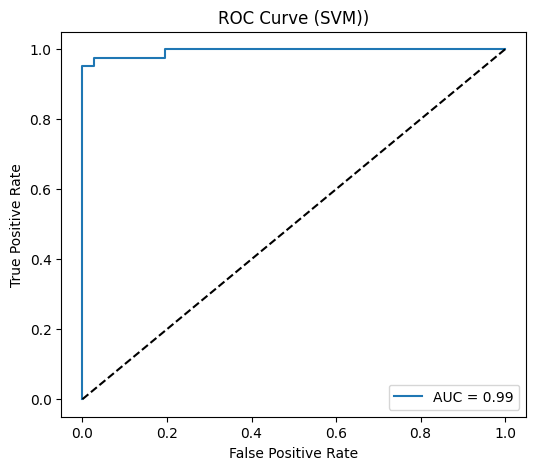

In [ ]:
svm_model=SVC(C=1,kernel='linear',probability=True)
svm_model.fit(x_train,y_train)
y_pred_svm=svm_model.predict(x_test)
y_proba_svm=svm_model.predict_proba(x_test)[:,1]
print("Classification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

# ✅ Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:")
print(cm)

# ✅ ROC-AUC score
roc_auc = roc_auc_score(y_test,y_proba_svm)
print("ROC-AUC:", roc_auc)

# ✅ Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_svm)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM))")
plt.legend()
plt.show()

                    Feature  Importance
6              radius_worst    2.266446
3            compactness_se    1.223481
7             texture_worst    1.167753
4              concavity_se    1.152492
9      concave points_worst    0.871507
2                 radius_se    0.618587
10           symmetry_worst    0.422678
8          smoothness_worst    0.282004
5         concave points_se    0.209461
0          compactness_mean    0.077729
1             symmetry_mean    0.071524
11  fractal_dimension_worst    0.013898


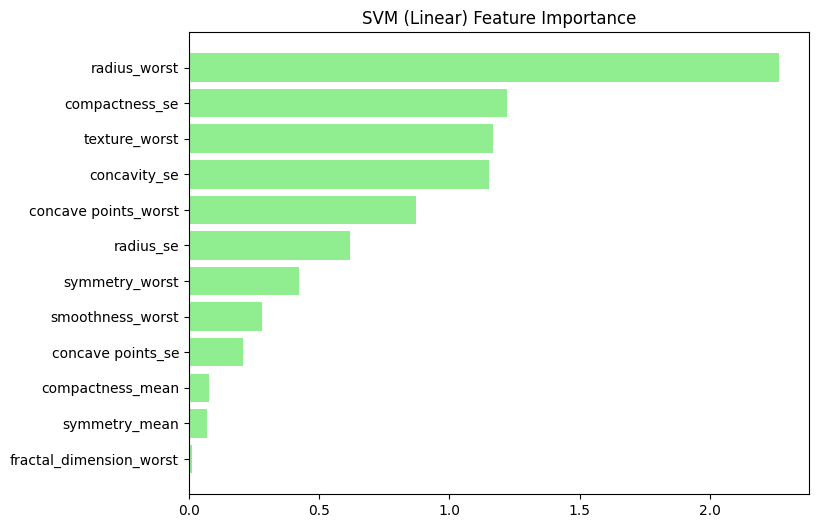

In [ ]:
svm_coefficients = svm_model.coef_[0]

svm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(svm_coefficients)
}).sort_values(by='Importance', ascending=False)

print(svm_importance)

plt.figure(figsize=(8,6))
plt.barh(svm_importance['Feature'], svm_importance['Importance'], color='lightgreen')
plt.title("SVM (Linear) Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(svm_model,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.96491228 0.95614035 0.93859649 0.99122807 0.98230088]
Mean CV accuracy: 0.9666356155876418
Std deviation: 0.018705627208683136



=== KNN with SMOTE ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
 [[71  1]
 [ 5 37]]
ROC-AUC: 0.9745370370370371


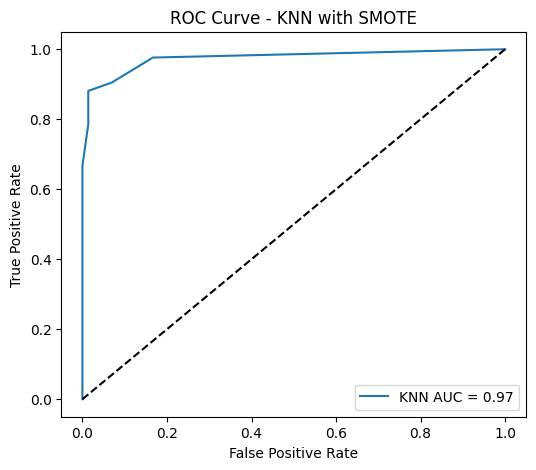

In [ ]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_knn=knn_model.predict(x_test)
y_proba_knn=knn_model.predict_proba(x_test)[:,1]
print("\n=== KNN with SMOTE ===")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"KNN AUC = {roc_auc_score(y_test, y_proba_knn):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN with SMOTE")
plt.legend()
plt.show()

                    Feature  Importance
6              radius_worst    0.085088
9      concave points_worst    0.045614
7             texture_worst    0.039474
2                 radius_se    0.038596
5         concave points_se    0.014912
8          smoothness_worst    0.012281
4              concavity_se    0.007895
0          compactness_mean    0.007895
1             symmetry_mean    0.007895
10           symmetry_worst    0.006140
3            compactness_se    0.003509
11  fractal_dimension_worst   -0.001754


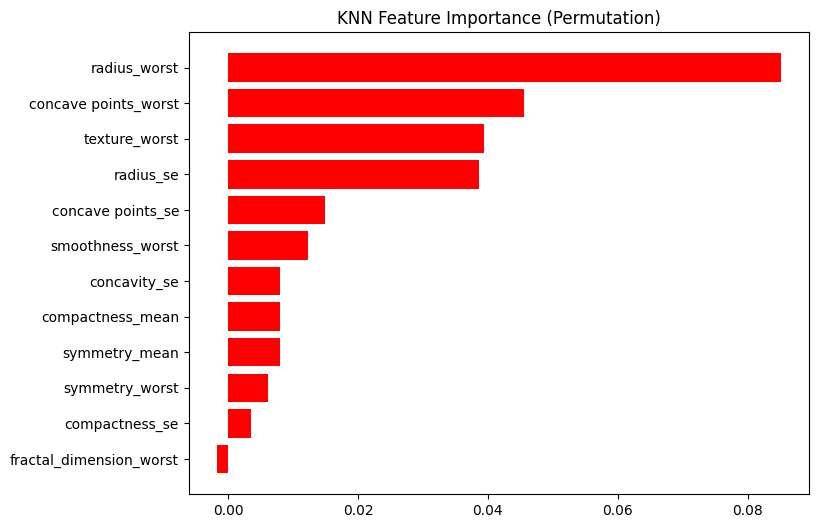

In [ ]:
result = permutation_importance(knn_model, x_test, y_test, n_repeats=10, random_state=42)

knn_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(knn_importance)

plt.figure(figsize=(8,6))
plt.barh(knn_importance['Feature'], knn_importance['Importance'], color='red')
plt.title("KNN Feature Importance (Permutation)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(knn_model,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.96491228 0.94736842 0.93859649 0.92982456 0.95575221]
Mean CV accuracy: 0.947290793355069
Std deviation: 0.012351344886321258


=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[72  0]
 [ 3 39]]
ROC-AUC: 0.9963624338624338


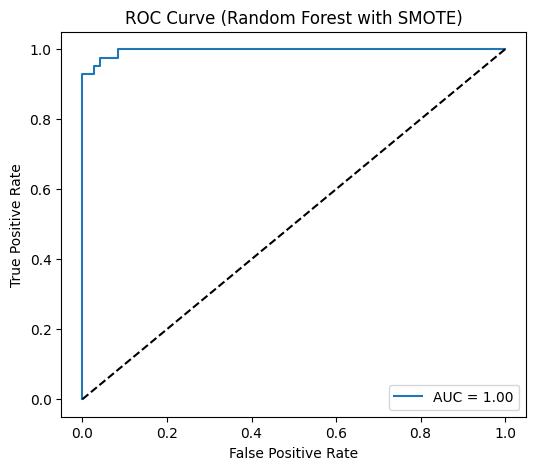

In [ ]:
rf_model=RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)
y_proba_rf = rf_model.predict_proba(x_test)[:,1]
y_pred_rf_train = rf_model.predict(x_train)

print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_rf):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest with SMOTE)")
plt.legend()
plt.show()

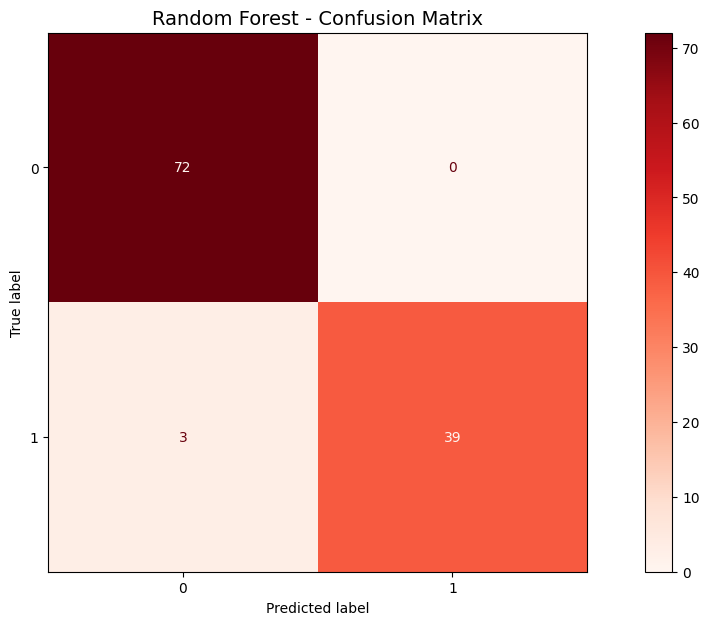

In [ ]:
cm=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf_model.classes_)
fig,ax=plt.subplots(figsize=(15,7))
disp.plot(cmap=plt.cm.Reds,ax=ax,values_format='d')
plt.title('Random Forest - Confusion Matrix',fontsize=14)
plt.savefig("conf_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

                    Feature  Importance
6              radius_worst    0.300893
9      concave points_worst    0.253680
2                 radius_se    0.111536
0          compactness_mean    0.095045
7             texture_worst    0.055797
10           symmetry_worst    0.041660
8          smoothness_worst    0.034904
5         concave points_se    0.031875
4              concavity_se    0.030489
11  fractal_dimension_worst    0.018405
3            compactness_se    0.013046
1             symmetry_mean    0.012670


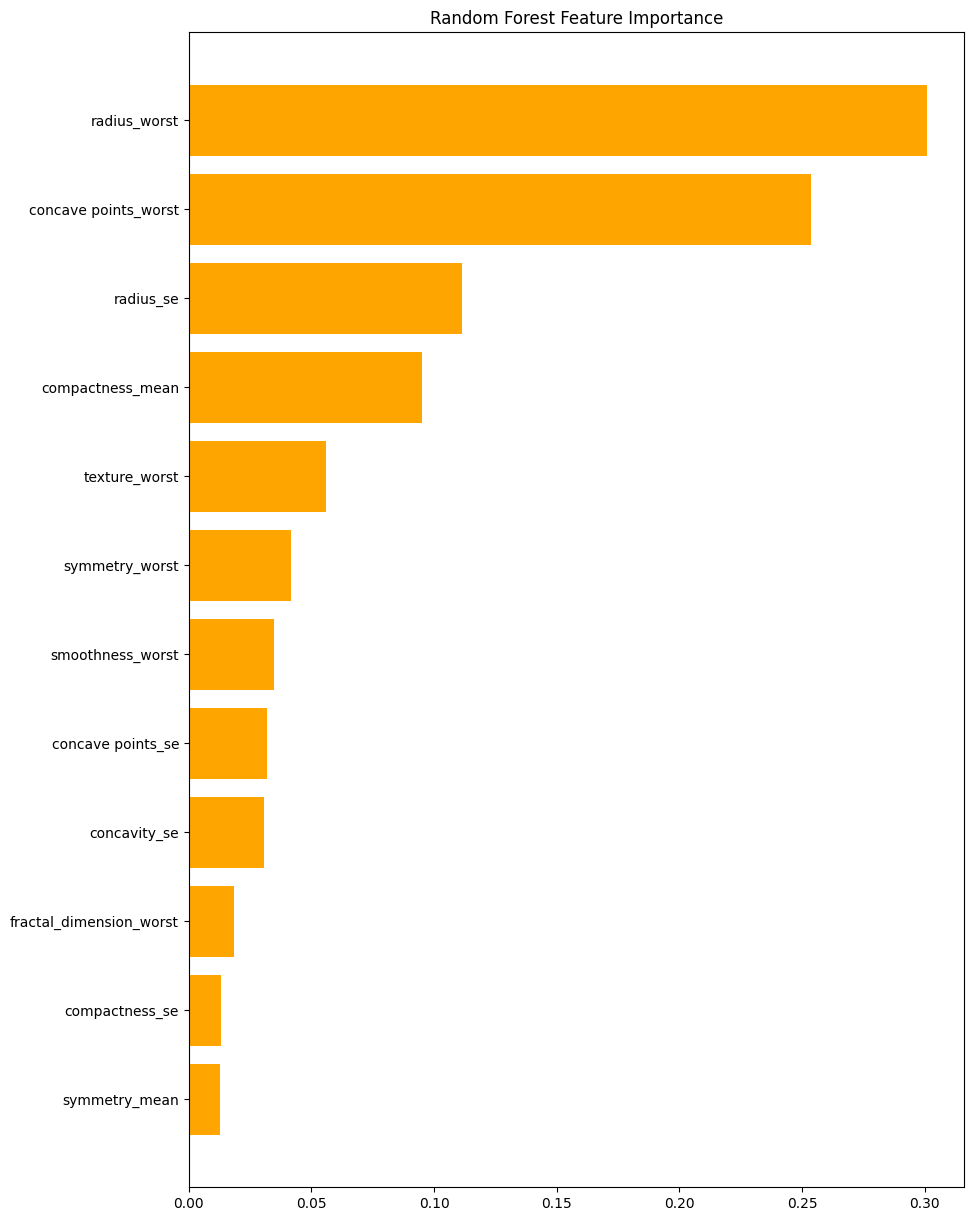

In [ ]:
feature_names=x_train.columns
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance)

plt.figure(figsize=(10,15))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='orange')
plt.title("Random Forest Feature Importance")
plt.savefig("feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.gca().invert_yaxis()
plt.show()

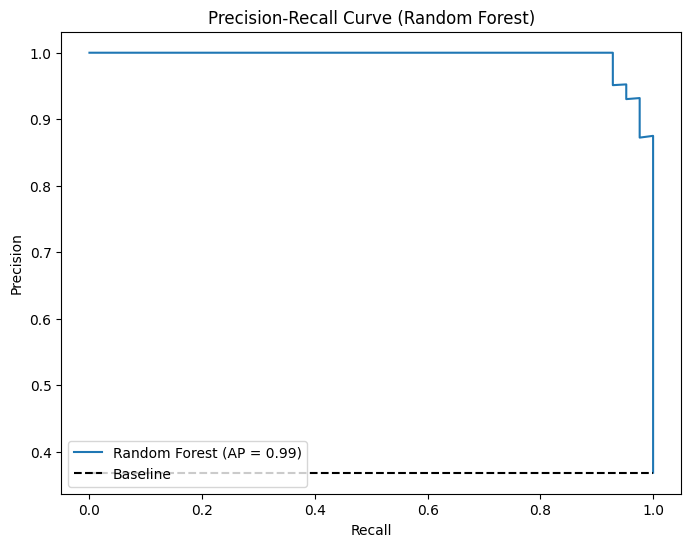

In [ ]:
y_proba_rf = rf_model.predict_proba(x_test)[:, 1]

# Compute precision-recall values
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)

# Compute average precision (AP)
avg_prec = average_precision_score(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"Random Forest (AP = {avg_prec:.2f})")

# Baseline: positive class ratio
baseline = y_test.mean()
plt.hlines(y=baseline, xmin=0, xmax=1, colors='k', linestyles='--', label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.legend(loc="lower left")
plt.savefig("AP_curve_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(rf_model,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.97368421 0.94736842 0.95614035 0.97368421 0.96460177]
Mean CV accuracy: 0.9630957925787922
Std deviation: 0.010219838955441115


=== Classification Report (SMOTE + Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
 [[71  1]
 [ 6 36]]
ROC-AUC: 0.996031746031746


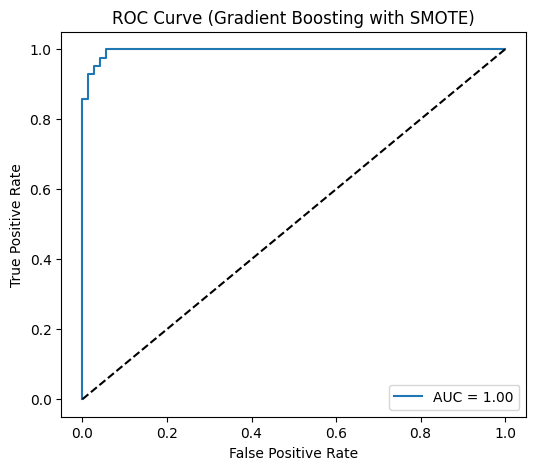

In [ ]:
gb_model = XGBClassifier(n_estimators=200, learning_rate=0.2, max_depth=3, random_state=42)
gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)
y_proba_gb = gb_model.predict_proba(x_test)[:,1]

print("=== Classification Report (SMOTE + Gradient Boosting) ===")
print(classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

fpr, tpr, _ = roc_curve(y_test, y_proba_gb)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_gb):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Gradient Boosting with SMOTE)")
plt.legend()
plt.show()

                    Feature  Importance
6              radius_worst    0.455634
9      concave points_worst    0.263861
7             texture_worst    0.072553
4              concavity_se    0.048071
2                 radius_se    0.039109
3            compactness_se    0.038498
8          smoothness_worst    0.022184
10           symmetry_worst    0.016888
5         concave points_se    0.015695
0          compactness_mean    0.014257
11  fractal_dimension_worst    0.009302
1             symmetry_mean    0.003949


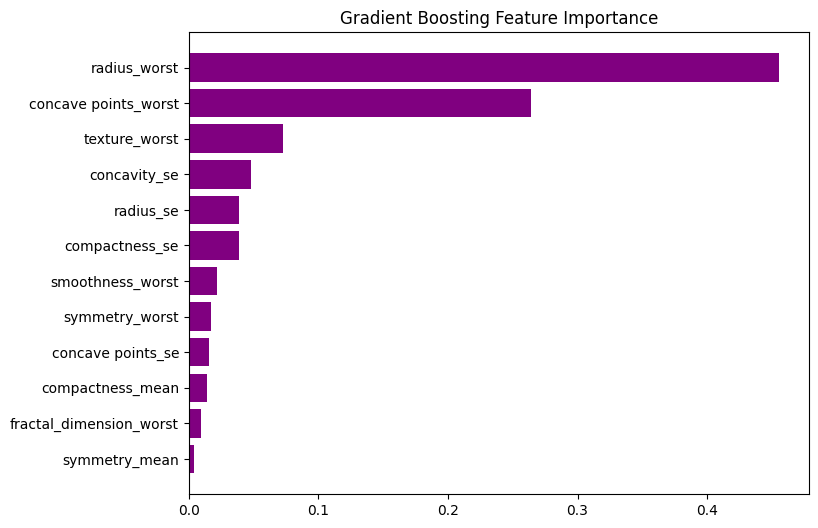

In [ ]:
gb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(gb_importance)

plt.figure(figsize=(8,6))
plt.barh(gb_importance['Feature'], gb_importance['Importance'], color='purple')
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(gb_model,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.97368421 0.95614035 0.95614035 0.96491228 0.94690265]
Mean CV accuracy: 0.9595559695699425
Std deviation: 0.009074541713341145


In [ ]:
estimator=[]
estimator.append(('Logistic Regression',lr_model))
estimator.append(('SVM',svm_model))
estimator.append(('KNN',knn_model))
estimator.append(('Random Forest',rf_model))
estimator.append(('Gradient Boosting',gb_model))

In [ ]:
VC_hard=VotingClassifier(estimators=estimator,voting='hard',weights=[3,1,1,1,1] )
VC_hard

VotingClassifier(estimators=[('Linear Regression', LogisticRegression()),
                             ('SVM',
                              SVC(C=1, kernel='linear', probability=True)),
                             ('KNN', KNeighborsClassifier()),
                             ('Random Forest',
                              RandomForestClassifier(n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('Gradient Boosting',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_byn...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.2, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 weights=[3, 1, 1, 1, 1])

In [ ]:
VC_hard.fit(x_train,y_train)

y_pred_vc=VC_hard.predict(x_test)
y_pred_vc_train = VC_hard.predict(x_train)

print("Classification Report (Voting Classifier - Hard):")
print(classification_report(y_test, y_pred_vc))

cm = confusion_matrix(y_test, y_pred_vc)
print("Confusion Matrix:")
print(cm)
print("Train Accuracy:", accuracy_score(y_train, y_pred_vc_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_vc))
print("Train F1:", f1_score(y_train, y_pred_vc_train))
print("Test F1:", f1_score(y_test, y_pred_vc))

Classification Report (Voting Classifier - Hard):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[72  0]
 [ 2 40]]
Train Accuracy: 0.9824175824175824
Test Accuracy: 0.9824561403508771
Train F1: 0.9761904761904762
Test F1: 0.975609756097561


In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(VC_hard,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.96491228 0.95614035 0.94736842 0.99122807 0.98230088]
Mean CV accuracy: 0.9683900015525537
Std deviation: 0.01624281617318955


In [ ]:
VC_soft=VotingClassifier(estimators=estimator,voting='soft',weights=[3,1,1,1,1])
VC_soft

VotingClassifier(estimators=[('Linear Regression', LogisticRegression()),
                             ('SVM',
                              SVC(C=1, kernel='linear', probability=True)),
                             ('KNN', KNeighborsClassifier()),
                             ('Random Forest',
                              RandomForestClassifier(n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('Gradient Boosting',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_byn...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.2, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft', weights=[3, 1, 1, 1, 1])

In [ ]:
VC_soft.fit(x_train,y_train)

y_pred_vc = VC_soft.predict(x_test)
y_pred_vc_train = VC_soft.predict(x_train)

print("Classification Report (Voting Classifier - Soft):")
print(classification_report(y_test, y_pred_vc))


cm = confusion_matrix(y_test, y_pred_vc)
print("Confusion Matrix:")
print(cm)
print("Train Accuracy:", accuracy_score(y_train, y_pred_vc_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_vc))
print("Train F1:", f1_score(y_train, y_pred_vc_train))
print("Test F1:", f1_score(y_test, y_pred_vc))

Classification Report (Voting Classifier - Soft):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[72  0]
 [ 2 40]]
Train Accuracy: 0.9934065934065934
Test Accuracy: 0.9824561403508771
Train F1: 0.9910979228486647
Test F1: 0.975609756097561


In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(VC_soft,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.97368421 0.96491228 0.95614035 0.99122807 0.97345133]
Mean CV accuracy: 0.9718832479428661
Std deviation: 0.011630629209317934
